# Notebook 02 - Fixed CARMA(4,3) ACF calibration

This notebook tests the reduced structure `Kr=2, Kc=1`: two real modes and one 24h oscillatory pair. The CARMA order is therefore fixed at `(4,3)`.

Only the 2024 deseasonalized log-price residuals from notebook 01 are used for calibration. The 2025 panel is left untouched for validation in notebook 03.


In [1]:
%matplotlib inline

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from scipy.linalg import expm, solve_continuous_lyapunov

plt.rcParams.update({
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CWD = Path.cwd().resolve()
if (CWD / "france" / "france24vs25" / "data" / "seasonality" / "price_panel_2024_train.csv").exists():
    PROJECT_ROOT = CWD
    CHECK_DIR = CWD / "france" / "france24vs25"
elif (CWD / "data" / "seasonality" / "price_panel_2024_train.csv").exists():
    CHECK_DIR = CWD
    PROJECT_ROOT = CWD.parent.parent
else:
    raise FileNotFoundError("Run this notebook from the repo root or from france/france24vs25/. Run notebook 01 first.")

SEAS = CHECK_DIR / "data" / "seasonality"
OUT = CHECK_DIR / "data" / "kalman"
FIG = CHECK_DIR / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

TRAIN_PANEL = SEAS / "price_panel_2024_train.csv"
panel_train = pd.read_csv(TRAIN_PANEL, index_col=0, parse_dates=True)
panel_train = panel_train.dropna(subset=["log_price_resid"])

if not (panel_train.index.year == 2024).all():
    raise ValueError("The training panel must contain 2024 observations only.")

pr = panel_train["log_price_resid"].to_numpy(float)
pr = pr[np.isfinite(pr)]
pr = pr - pr.mean()
N = len(pr)
v0 = float(pr @ pr / N)

def acf(k):
    k = int(k)
    return 1.0 if k == 0 else float(pr[:-k] @ pr[k:] / ((N - k) * v0))

lags = np.concatenate([
    np.arange(1, 337),
    np.array([384, 432, 504, 600, 720, 960, 1200, 1440, 1800, 2160, 2520]),
])
if lags.max() >= N:
    raise ValueError(f"Max ACF lag {lags.max()} must be smaller than sample size {N}.")

rho_emp = np.array([acf(k) for k in lags])
nlag = len(lags)

wts = 1 / np.sqrt(lags.astype(float))
wts[lags <= 72] *= 2
wts[lags >= 168] *= 2
for anchor in [1, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 336, 720, 1440, 2160, 2520]:
    wts[lags == anchor] *= 8
sw = np.sqrt(wts / wts.mean())

def softmax(z):
    z = np.asarray(z, dtype=float)
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()

print(f"Input panel: {TRAIN_PANEL}")
print(f"{N:,} hourly 2024 deseasonalized log-price residuals")
print(f"variance target v0 = {v0:.6e}")
print(f"ACF target lags: {nlag} lags, 1h to {lags.max()}h")


Input panel: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\carmacheck\data\seasonality\price_panel_2024_train.csv
8,784 hourly 2024 deseasonalized log-price residuals
variance target v0 = 5.638792e-04
ACF target lags: 347 lags, 1h to 2520h


## 1. Fixed multiscale ACF structure

The model structure is fixed as `Kr=2, Kc=1`, with the oscillatory pair locked to a 24h period. The optimization recalibrates only the half-lives and variance shares on 2024.


kind,half_life_h,half_life_d,period_h,share
osc,48.00,2.00,24.0,0.028
real,1.29,0.05,inf,0.124
real,26.34,1.10,inf,0.848


RMSE=0.060306  WSSR=0.6125  (CARMA order 4)


lag_h,empirical,model,err
1,0.9327,0.9253,-0.0074
2,0.8635,0.8707,+0.0072
3,0.8104,0.8276,+0.0172
6,0.7087,0.7294,+0.0207
12,0.6096,0.5953,-0.0143
18,0.5241,0.5282,+0.0041
24,0.5004,0.4709,-0.0296
30,0.3737,0.3852,+0.0115
48,0.2632,0.2538,-0.0094
72,0.1552,0.1374,-0.0177


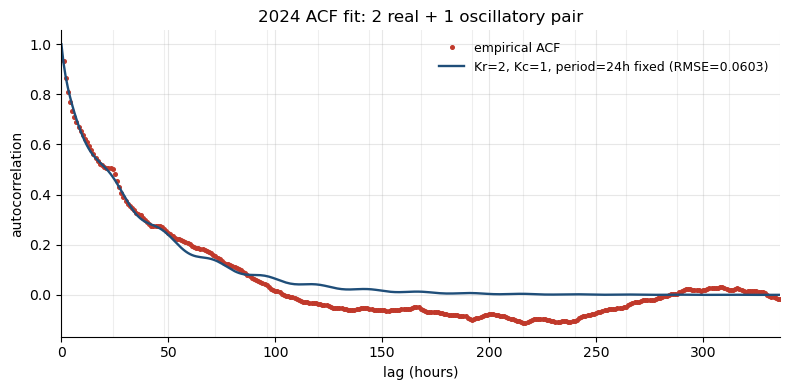

Saved: price_carma43_2024_acf_multiscale_fit.png


In [2]:
Kr, Kc = 2, 1
m = Kr + Kc
om_c_fixed = np.array([2 * np.pi / 24.0])

def rho_24(theta, k):
    kap = np.log(2) / np.exp(theta[:m])
    sh = softmax(theta[m:2 * m])
    h = np.asarray(k, dtype=float)

    out = np.zeros_like(h, dtype=float)
    for i in range(Kr):
        out += sh[i] * np.exp(-kap[i] * h)
    for j in range(Kc):
        idx = Kr + j
        out += sh[idx] * np.exp(-kap[idx] * h) * np.cos(om_c_fixed[j] * h)
    return out


max_half_life_h = 70.0 * 24.0
lb_hl = [np.log(0.3)] * Kr + [np.log(48.0)] * Kc
ub_hl = [np.log(max_half_life_h)] * m
lb = lb_hl + [-9.0] * m
ub = ub_hl + [9.0] * m

start_hl = [
    [1.3, 26.0, 48.0],
    [4.0, 24.0, 96.0],
    [8.0, 36.0, 96.0],
    [1.2, 34.0, 100.0],
    [10.0, 1500.0, 96.0],
]

rng = np.random.default_rng(42)
best = None
n_starts = 64
for s in range(n_starts):
    if s < len(start_hl):
        xs = np.r_[np.log(start_hl[s]), [0.0] * m]
    else:
        xs = np.r_[np.log(start_hl[s % len(start_hl)]), [0.0] * m]
        xs[:m] += rng.normal(0, 0.55, m)
        xs[m:2 * m] += rng.normal(0, 1.1, m)
    xs = np.clip(xs, lb, ub)
    r = least_squares(
        lambda t: sw * (rho_24(t, lags) - rho_emp),
        xs,
        bounds=(lb, ub),
        max_nfev=7000,
    )
    if best is None or r.cost < best.cost:
        best = r

kap_b = np.log(2) / np.exp(best.x[:m])
sh_b = softmax(best.x[m:2 * m])

rows = []
for i in range(Kr):
    hl_h = np.log(2) / kap_b[i]
    rows.append({
        "kind": "real",
        "half_life_h": hl_h,
        "half_life_d": hl_h / 24.0,
        "period_h": np.inf,
        "share": sh_b[i],
    })
for j in range(Kc):
    idx = Kr + j
    hl_h = np.log(2) / kap_b[idx]
    rows.append({
        "kind": "osc",
        "half_life_h": hl_h,
        "half_life_d": hl_h / 24.0,
        "period_h": 24.0,
        "share": sh_b[idx],
    })

summary_24 = pd.DataFrame(rows).sort_values(["kind", "half_life_h"]).reset_index(drop=True)
display(summary_24.style.format({
    "half_life_h": "{:.2f}",
    "half_life_d": "{:.2f}",
    "period_h": "{:.1f}",
    "share": "{:.3f}",
}).hide(axis="index"))

rmse_24 = float(np.sqrt(np.mean((rho_24(best.x, lags) - rho_emp) ** 2)))
wssr_24 = float(np.sum((sw * (rho_24(best.x, lags) - rho_emp)) ** 2))
print(f"RMSE={rmse_24:.6f}  WSSR={wssr_24:.4f}  (CARMA order {Kr + 2 * Kc})")

diag = [1, 2, 3, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 336, 720, 1440, 2160]
cmp = pd.DataFrame({
    "lag_h": diag,
    "empirical": [acf(k) for k in diag],
    "model": rho_24(best.x, np.array(diag, dtype=float)),
})
cmp["err"] = cmp["model"] - cmp["empirical"]
display(cmp.style.format({"empirical": "{:.4f}", "model": "{:.4f}", "err": "{:+.4f}"}).hide(axis="index"))

kk = np.arange(0, 721)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, 337), [acf(k) for k in range(1, 337)],
        "o", ms=2.6, color="#c0392b", label="empirical ACF")
ax.plot(kk, rho_24(best.x, kk), "-", lw=1.7, color="#1f4e79",
        label=f"Kr=2, Kc=1, period=24h fixed (RMSE={rmse_24:.4f})")
for d in range(24, 337, 24):
    ax.axvline(d, color="#eeeeee", lw=0.8, zorder=0)
ax.set_xlim(0, 336)
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
ax.set_title("2024 ACF fit: 2 real + 1 oscillatory pair")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
fig_path = FIG / "price_carma43_2024_acf_multiscale_fit.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")


## 2. Spectral factorization and CARMA(4,3) export

The spectral factorization converts the fitted multiscale covariance into CARMA coefficients. The highest-order MA coefficient is normalized to one, following the book convention used by notebook 03.


P(u) degree=3  leading=1.0049e-04  (expected 2v0*sum(kappa*w)=1.0049e-04)
All b roots Re<0: True  |  max Re=-2.46e-02
b = [0.018535, 0.08187 , 0.319373, 1.      ]
b^T P_norm b = 5.6113e+00  (v0=5.6388e-04)

=== ACF verification ===
  Multiscale model  RMSE=0.060306  WSSR=0.6125
  Spectral b        RMSE=0.060306  WSSR=0.6125
  Delta RMSE = -6.94e-18  (should be close to 0)


lag_h,empirical,multiscale,"CARMA(4,3) sf-b",err_sf
1,0.9327,0.9253,0.9253,-0.0074
2,0.8635,0.8707,0.8707,0.0072
3,0.8104,0.8276,0.8276,0.0172
6,0.7087,0.7294,0.7294,0.0207
12,0.6096,0.5953,0.5953,-0.0143
18,0.5241,0.5282,0.5282,0.0041
24,0.5004,0.4709,0.4709,-0.0296
30,0.3737,0.3852,0.3852,0.0115
48,0.2632,0.2538,0.2538,-0.0094
72,0.1552,0.1374,0.1374,-0.0177


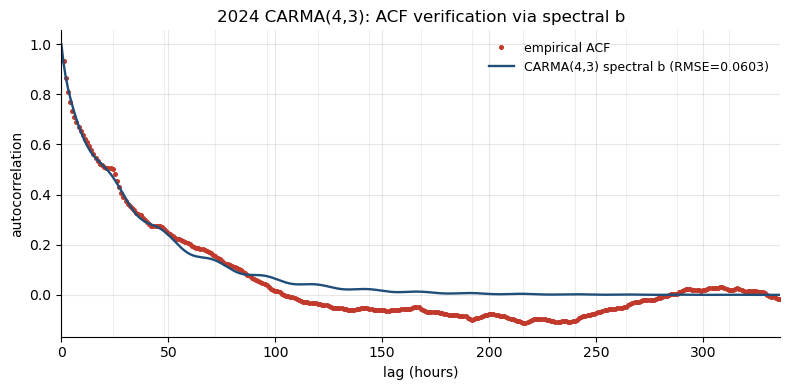

Saved: price_carma43_2024_acf_spectral_fit.png
saved: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\carmacheck\data\kalman\price_multiscale_carma_selected.json
saved: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\carmacheck\data\kalman\price_carma_b_init.json
saved: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\carmacheck\data\kalman\price_multiscale_carma_selected_components.csv
saved: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\carmacheck\data\kalman\price_carma43_acf_diagnostics.csv

=== Init for nb03: p=4, q=3 ===
  b = [0.018535, 0.08187 , 0.319373, 1.      ]


In [3]:
kap_r = kap_b[:Kr]
sh_r = sh_b[:Kr]
kap_c = kap_b[Kr:]
sh_c = sh_b[Kr:]
om_c = om_c_fixed.copy()
p = Kr + 2 * Kc

roots_ar = [complex(-kap_r[i], 0.0) for i in range(Kr)]
for j in range(Kc):
    roots_ar.extend([
        complex(-kap_c[j], om_c[j]),
        complex(-kap_c[j], -om_c[j]),
    ])
ar = np.real(np.poly(roots_ar)[1:])

A = np.zeros((p, p))
for i in range(p - 1):
    A[i, i + 1] = 1.0
A[-1, :] = -ar[::-1]
ep = np.zeros(p)
ep[-1] = 1.0
P_norm = solve_continuous_lyapunov(A, -np.outer(ep, ep))

fp_r2 = lambda k: np.array([1.0, k ** 2])
fp_c2 = lambda k, o: np.array([1.0, 2 * (k ** 2 - o ** 2), (k ** 2 + o ** 2) ** 2])
fr2 = [fp_r2(k) for k in kap_r]
fc2 = [fp_c2(k, o) for k, o in zip(kap_c, om_c)]

P_u = np.zeros(p)
for i in range(Kr):
    t = np.array([2 * kap_r[i] * sh_r[i] * v0])
    for i2 in range(Kr):
        if i2 != i:
            t = np.polymul(t, fr2[i2])
    for j in range(Kc):
        t = np.polymul(t, fc2[j])
    P_u = np.polyadd(P_u, t)

for j in range(Kc):
    t = np.polymul(
        np.array([2 * kap_c[j] * sh_c[j] * v0]),
        np.array([1.0, kap_c[j] ** 2 + om_c[j] ** 2]),
    )
    for i in range(Kr):
        t = np.polymul(t, fr2[i])
    for j2 in range(Kc):
        if j2 != j:
            t = np.polymul(t, fc2[j2])
    P_u = np.polyadd(P_u, t)

expected_leading = 2 * v0 * float(np.r_[kap_r, kap_c] @ sh_b)
print(f"P(u) degree={len(P_u) - 1}  leading={P_u[0]:.4e}  "
      f"(expected 2v0*sum(kappa*w)={expected_leading:.4e})")

u_roots = np.roots(P_u)
b_roots = np.array([
    1j * np.sqrt(uk) if np.real(1j * np.sqrt(uk)) < np.real(-1j * np.sqrt(uk))
    else -1j * np.sqrt(uk)
    for uk in u_roots
])
print(f"All b roots Re<0: {np.all(np.real(b_roots) < 0)}  |  max Re={np.max(np.real(b_roots)):.2e}")

b_vec_raw = np.real(np.poly(b_roots)[::-1])
b_vec = b_vec_raw / b_vec_raw[-1]
Pb = P_norm @ b_vec
var0 = float(b_vec @ Pb)
print(f"b = {np.array2string(b_vec, precision=6, separator=', ')}")
print(f"b^T P_norm b = {var0:.4e}  (v0={v0:.4e})")

eAh = np.stack([expm(A * float(h)) for h in lags])
rho_sf = (eAh @ Pb) @ b_vec / var0
rmse_sf = float(np.sqrt(np.mean((rho_sf - rho_emp) ** 2)))
wssr_sf = float(np.sum((sw * (rho_sf - rho_emp)) ** 2))
print("\n=== ACF verification ===")
print(f"  Multiscale model  RMSE={rmse_24:.6f}  WSSR={wssr_24:.4f}")
print(f"  Spectral b        RMSE={rmse_sf:.6f}  WSSR={wssr_sf:.4f}")
print(f"  Delta RMSE = {rmse_sf - rmse_24:.2e}  (should be close to 0)")

diag = [1, 2, 3, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 336, 720, 1440, 2160]
eAhd = np.stack([expm(A * float(h)) for h in diag])
cmp_sf = pd.DataFrame({
    "lag_h": diag,
    "empirical": [acf(k) for k in diag],
    "multiscale": rho_24(best.x, np.array(diag, dtype=float)),
    f"CARMA({p},{p - 1}) sf-b": (eAhd @ Pb) @ b_vec / var0,
})
cmp_sf["err_sf"] = cmp_sf[f"CARMA({p},{p - 1}) sf-b"] - cmp_sf["empirical"]
display(cmp_sf.style.format({c: "{:.4f}" for c in cmp_sf.columns[1:]}).hide(axis="index"))

kk = np.arange(0, 721)
eAhp = np.stack([expm(A * float(h)) for h in kk])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, 337), [acf(k) for k in range(1, 337)],
        "o", ms=2.6, color="#c0392b", label="empirical ACF")
ax.plot(kk, (eAhp @ Pb) @ b_vec / var0, "-", lw=1.7, color="#1f4e79",
        label=f"CARMA({p},{p - 1}) spectral b (RMSE={rmse_sf:.4f})")
for d in range(24, 337, 24):
    ax.axvline(d, color="#eeeeee", lw=0.8, zorder=0)
ax.set_xlim(0, 336)
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
ax.set_title(f"2024 CARMA({p},{p - 1}): ACF verification via spectral b")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
fig_path = FIG / "price_carma43_2024_acf_spectral_fit.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")

def _ser(x):
    return None if (isinstance(x, float) and not np.isfinite(x)) else float(x)

components = [
    {
        "kind": str(r["kind"]),
        "half_life_h": float(r["half_life_h"]),
        "half_life_d": float(r["half_life_d"]),
        "period_h": _ser(r["period_h"]),
        "share": float(r["share"]),
    }
    for _, r in summary_24.iterrows()
]

payload = dict(
    selected=dict(Kr=Kr, Kc=Kc, order=p),
    roots=[[float(r.real), float(r.imag)] for r in roots_ar],
    ar_coefficients=[float(x) for x in ar],
    b_coefficients=[float(x) for x in b_vec],
    metrics=dict(
        rmse_multiscale=float(rmse_24),
        wssr_multiscale=float(wssr_24),
        rmse_spectral=float(rmse_sf),
        wssr_spectral=float(wssr_sf),
    ),
    components=components,
    calibration=dict(
        sample="2024_train",
        input_file=str(TRAIN_PANEL.relative_to(CHECK_DIR)),
        n_obs=int(N),
        variance_target=float(v0),
        mean_removed=True,
    ),
    note="Kr=2 Kc=1 period=24h fixed; all half-lives <= 70 days. CARMA(4,3). Monic b[-1]=1 (book convention).",
)

selected_path = OUT / "price_multiscale_carma_selected.json"
b_init_path = OUT / "price_carma_b_init.json"
components_path = OUT / "price_multiscale_carma_selected_components.csv"
acf_diag_path = OUT / "price_carma43_acf_diagnostics.csv"

selected_path.write_text(json.dumps(payload, indent=2))
b_init_path.write_text(json.dumps(dict(
    b_coefficients=[float(x) for x in b_vec],
    AR_order=int(p),
    MA_order=int(p - 1),
    acf_rmse_spectral=float(rmse_sf),
    acf_rmse_multiscale=float(rmse_24),
    calibration_sample="2024_train",
    source=str(TRAIN_PANEL.relative_to(CHECK_DIR)),
    note=f"CARMA({p},{p - 1}) spectral b. Monic b[-1]=1 (book convention).",
), indent=2))

summary_24.to_csv(components_path, index=False)
cmp_sf.to_csv(acf_diag_path, index=False)

print(f"saved: {selected_path}")
print(f"saved: {b_init_path}")
print(f"saved: {components_path}")
print(f"saved: {acf_diag_path}")
print(f"\n=== Init for nb03: p={p}, q={p - 1} ===")
print(f"  b = {np.array2string(b_vec, precision=6, separator=', ')}")
